# Preprocessing and function

In [20]:
# Libraries import
import pandas as pd
from collections import defaultdict
from pathlib import Path
from typing import Union, List, Optional, Dict
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import gzip, re
 

In [21]:
# Compute shotting chain function
def compute_shot_chain_scores(
    df,
    k=4,
    weights: list = None,                    # e.g., [0.1, 0.1, 0.2, 0.5] (farthest -> shooter)
    terminal_action='Shot',
    team=None,                               # filter to a specific team; None = all teams
    unique_in_chain=True,                    # don't credit the same player twice within a chain
    eligible_types=None,                     # which actions count before the shot
    id_col='ID',
    team_col='Team',
    player_col='Player Code',
    action_col='Action Type',
    labels_col='Additional Labels',
    goal_shot_weight=0.7,                    # shooter weight to use when the shot is a Goal
    goal_weight_mode='override'              # 'override' (default) or 'bonus'
):
    """
    Aggregate weighted credits to the last `k` players in each shot chain (including the shooter).
    Returns a DataFrame with columns: [Team, Player, TotalScore].

    weights: list of length k, ordered from farthest in the chain to the shooter.
             If a chain has < k players, the *suffix* of weights is used so the shooter
             always aligns with the last weight.
    If the shot has 'Goal' in `labels_col`:
      - goal_weight_mode='override' -> replace shooter weight with `goal_shot_weight`
      - goal_weight_mode='bonus'    -> add `goal_shot_weight` to the shooter weight
    """
    # defaults
    if eligible_types is None:
        eligible_types = {'Touch', 'Pass', 'Duel', 'Free kick', 'Throw in',
       'Interception', 'Clearance', 'Goal kick', 'Corner',
       'Shot against', }
    if weights is None:
        weights = [0.1, 0.1, 0.2, 0.5]
    if len(weights) != k:
        raise ValueError(f"`weights` length ({len(weights)}) must equal k ({k}).")

    df = df.copy().sort_values(id_col).reset_index(drop=True)

    # shots (optionally by team)
    shot_mask = df[action_col].eq(terminal_action)
    if team is not None:
        shot_mask &= df[team_col].eq(team)
    shot_idxs = df.index[shot_mask].tolist()

    totals = defaultdict(float)

    for si in shot_idxs:
        shot_row  = df.loc[si]
        shot_team = shot_row[team_col]
        shooter   = shot_row[player_col]

        # build chain: start with shooter (end of chain)
        chain_players = [shooter]
        seen = {shooter} if unique_in_chain else set()

        # walk backward through same-team, eligible actions to gather up to k-1 more players
        j = si - 1
        while j >= 0 and len(chain_players) < k and df.at[j, team_col] == shot_team:
            if df.at[j, action_col] in eligible_types:
                p = df.at[j, player_col]
                if (not unique_in_chain) or (p not in seen):
                    chain_players.append(p)   # closest-first while walking backward
                    seen.add(p)
            j -= 1

        # farthest -> shooter to match weights
        chain_players = list(reversed(chain_players))
        m = len(chain_players)
        w = weights[-m:]  # keep shooter aligned to the last weight

        # goal-sensitive shooter weight
        labs = str(shot_row.get(labels_col) or '').lower()
        if 'goal' in labs:
            if goal_weight_mode == 'override':
                w[-1] = goal_shot_weight
            elif goal_weight_mode == 'bonus':
                w[-1] = w[-1] + goal_shot_weight

        # accumulate
        for player, weight in zip(chain_players, w):
            totals[(shot_team, player)] += weight

    out = (
        pd.DataFrame([(t, p, s) for (t, p), s in totals.items()],
                     columns=[team_col, player_col, 'TotalScore'])
        .sort_values([team_col, 'TotalScore'], ascending=[True, False])
        .reset_index(drop=True)
    )
    return out


In [22]:
# Function adding appropriate team name to 
def add_team_name(df, first_team, first_team_players,
                  second_team=None, second_team_players=None,
                  player_code="Player Code"):
    mapping = {p.strip(): first_team for p in (first_team_players or [])}
    if second_team and second_team_players:
        mapping.update({p.strip(): second_team for p in second_team_players})
    df = df.copy()
    df[player_code] = df[player_code].astype(str).str.strip()
    df["Team"] = df[player_code].map(mapping)
    return df

In [23]:
# Read player data file(s) function

def parse_player_data_xml(
    folder: Union[str, Path],
    files: Union[str, List[str]],
    numeric_cols: Optional[List[str]] = None,
    combine: bool = True
) -> Union[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Parse one or many 'Player-based' soccer XML files into pandas DataFrame(s).
    - Tolerant to gzip, BOM/junk bytes, and encoding quirks
    - Skips bad files but processes the rest
    - Adds 'Source File' when combine=True
    """

    # ---- helpers ----
    ILLEGAL_XML_RE = re.compile(r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]")

    def _safe_cast(val, typ):
        try:
            return typ(val) if val is not None else None
        except (ValueError, TypeError):
            return None

    def _read_xml_text_robust(path: Path) -> str:
        raw = path.read_bytes()
        # gzip magic
        if raw[:2] == b"\x1f\x8b":
            raw = gzip.decompress(raw)
        # decode (handle BOM with utf-8-sig)
        for enc in ("utf-8-sig", "utf-16", "cp1252"):
            try:
                text = raw.decode(enc)
                break
            except UnicodeDecodeError:
                continue
        else:
            text = raw.decode("latin-1", errors="replace")
        # strip anything before first '<' and illegal control chars
        i = text.find("<")
        if i > 0:
            text = text[i:]
        return ILLEGAL_XML_RE.sub("", text)

    def _parse_one(path: Path) -> pd.DataFrame:
        # Load + parse root
        text = _read_xml_text_robust(path)
        try:
            root = ET.fromstring(text)
        except ET.ParseError as e:
            # HTML or non-XML? (don't crash—just skip)
            head = text[:80].strip().replace("\n", " ")
            raise ValueError(f"{path.name}: not well-formed XML ({e}); head starts: {head!r}")

        # Extract rows from <instance> nodes
        rows = []
        for inst in root.findall(".//instance"):
            row = {
                "ID": _safe_cast(inst.findtext("ID"), int),
                "Player Code": inst.findtext("code"),
                "Start Time": _safe_cast(inst.findtext("start"), float),
                "End Time": _safe_cast(inst.findtext("end"), float),
            }
            labels = [lab.findtext("text") for lab in inst.findall("label") if lab.findtext("text")]
            row["Action Type"] = labels[0] if labels else None
            row["Additional Labels"] = ", ".join(labels[1:]) if len(labels) > 1 else ""
            rows.append(row)

        df = pd.DataFrame(rows)
        if numeric_cols:
            for c in numeric_cols:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.reset_index(drop=True)

    def _expand_paths(folder: Path, items: List[str]) -> List[Path]:
        out = []
        for it in items:
            if any(ch in it for ch in "*?[]"):            # glob support if you need it
                out.extend(sorted((folder).glob(it)))
            else:
                out.append((folder / it))
        # dedupe but keep order
        seen, uniq = set(), []
        for p in out:
            if p not in seen:
                seen.add(p); uniq.append(p)
        return uniq

    # ---- main ----
    folder = Path(folder)
    if isinstance(files, str):
        files = [files]
    paths = _expand_paths(folder, files)
    if not paths:
        raise FileNotFoundError(f"No files matched {files} in {folder}")

    if combine:
        frames, skipped = [], []
        for p in paths:
            try:
                if not p.exists():
                    skipped.append(f"{p.name}: missing file")
                    continue
                df = _parse_one(p)
                if df.empty:
                    skipped.append(f"{p.name}: parsed but no <instance> rows")
                    continue
                df.insert(0, "Source File", p.name)
                frames.append(df)
            except Exception as e:
                skipped.append(str(e))
        if skipped:
            print("⚠️ Skipped/issue files:\n - " + "\n - ".join(skipped))
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(
            columns=["Source File","ID","Player Code","Start Time","End Time","Action Type","Additional Labels"]
        )
    else:
        out, skipped = {}, []
        for p in paths:
            try:
                if not p.exists():
                    skipped.append(f"{p.name}: missing file"); continue
                df = _parse_one(p)
                out[p.name] = df
            except Exception as e:
                skipped.append(str(e))
        if skipped:
            print("⚠️ Skipped/issue files:\n - " + "\n - ".join(skipped))
        return out


# 

# Ana

In [24]:
team = 'Utah Utes'
base_path = '/Users/hungduong/Documents/MSBA UofU/MSBA 3rd/UofU-Soccer-Analytics'

team_based_files = [
        "Utah Utes - NC State Wolfpack 3-0 (Player-based).xml",
        #"Utah Utes - Westminster Griffins 4-0 (Player-based).xml",
        "Utah Valley Wolverines - Utah Utes 2-0 (Player-based).xml",
        "Gonzaga Bulldogs - Utah Utes 1-2 (Player-based).xml",
        "Utah St. Aggies - Utah Utes 1-1 (Player-based).xml",
        "Utah Utes - LSU Tigers 0-2 (Player-based).xml",
        "Utah Utes - Oregon State Beavers 1-2 (Player-based).xml",
        "Utah Utes - Utah Tech Trailblazers 2-1 (Player-based).xml",
        "Washington Huskies - Utah Utes 0-1 (Player-based).xml"
        ]


players = ["1. Gibbs", "3. Blaylock", "12. Paugh", "15. Hetzel", "17. Cull",
    "21. Swensen", "6. Dudley", "10. Lovell", "18. Blum", "7. Bullock", "9. Watkins",
    "16. Park", "26. Kennel", "11. Davidson", "14. Julia Oka", "5. Affleck",
    "20. Bellini", "24. Woods", "22. Encinas", "23. Callaway", "4. A.Schoenstadt","2. Blaylock"]


avg_minute_per_game = [90, 90, 90,90,75, 72.3,90,88.3,79.7,90,90,43 ,50.5,50,7,40.9,33.3,62.3,20,18,13.5,50.3  ]

In [25]:
player_based_files = [f.replace("Team-based", "Player-based") for f in team_based_files]


player_data = parse_player_data_xml(
    folder=f"{base_path}/{team}",
    files=player_based_files,
    numeric_cols=["ID", "Start Time", "End Time"])

In [29]:
player_data = add_team_name(player_data, first_team = team, 
    first_team_players =  players,
    second_team = "Others", 
    second_team_players =  [])

In [33]:
average_playtime = dict(zip(players, avg_minute_per_game))
average_playtime.pop("14. Julia Oka", None) 

7

In [34]:
# Compute sore with made function
chain_scores_utah = compute_shot_chain_scores(player_data, k=4, weights=[0.1, 0.2, 0.3, 0.5], team= "Utah Utes",
                                       goal_shot_weight=0.7, goal_weight_mode='override')

# Map average playtime to each players (eyeballing from wyscout)

chain_scores_utah['avg_play_time'] = chain_scores_utah['Player Code'].map(average_playtime) 

# Calculate score per 90 minutes
chain_scores_utah['score_per_match'] = (chain_scores_utah['TotalScore']/(chain_scores_utah['avg_play_time']*4))*90

# Result
chain_scores_utah = chain_scores_utah.sort_values('score_per_match', ascending=False)
print(chain_scores_utah)

         Team    Player Code  TotalScore  avg_play_time  score_per_match
0   Utah Utes     9. Watkins        13.0           90.0         3.250000
1   Utah Utes     7. Bullock        12.5           90.0         3.125000
2   Utah Utes       18. Blum         9.7           79.7         2.738394
3   Utah Utes    21. Swensen         8.3           72.3         2.582988
4   Utah Utes     15. Hetzel         7.5           90.0         1.875000
11  Utah Utes     5. Affleck         3.0           40.9         1.650367
5   Utah Utes    3. Blaylock         6.6           90.0         1.650000
10  Utah Utes      24. Woods         4.3           62.3         1.552970
7   Utah Utes       17. Cull         4.6           75.0         1.380000
13  Utah Utes       16. Park         2.3           43.0         1.203488
6   Utah Utes     10. Lovell         4.6           88.3         1.172140
8   Utah Utes      12. Paugh         4.5           90.0         1.125000
9   Utah Utes      6. Dudley         4.4           

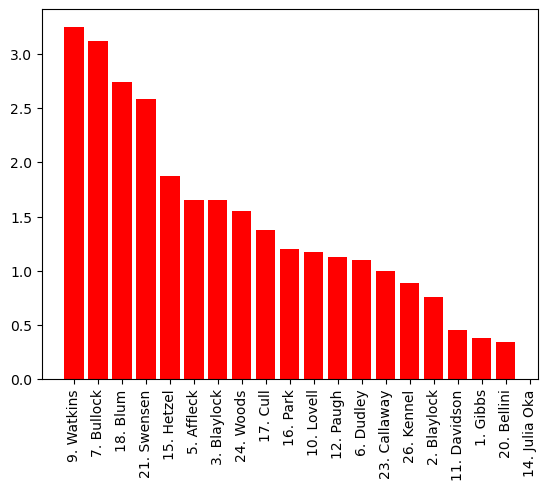

In [35]:
plt.bar(
    chain_scores_utah['Player Code'],
    chain_scores_utah['score_per_match'],
    color= 'red'
    )

plt.xticks(rotation=90)
plt.show()

posx and posy should be finite values
posx and posy should be finite values


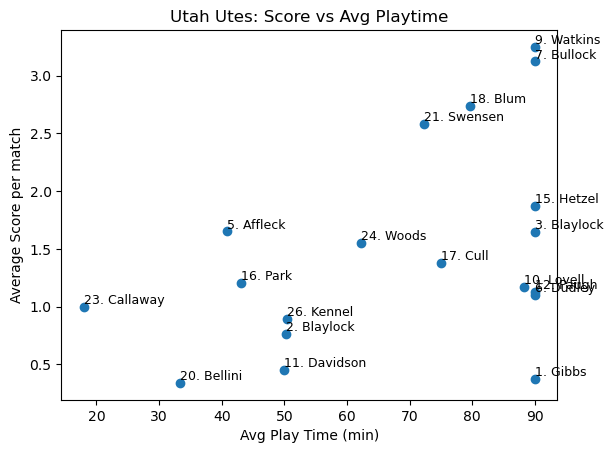

<Figure size 700x1000 with 0 Axes>

In [36]:
# scatter plot: play time vs score
plt.scatter(chain_scores_utah["avg_play_time"], chain_scores_utah["score_per_match"])

# add labels (Player Code)
for i, row in chain_scores_utah.iterrows():
    plt.text(
        row["avg_play_time"], 
        row["score_per_match"], 
        row["Player Code"], 
        fontsize=9, 
        ha="left", 
        va="bottom"
    )

plt.xlabel("Avg Play Time (min)")
plt.ylabel("Average Score per match")
plt.title("Utah Utes: Score vs Avg Playtime")
plt.figure(figsize=(7, 10))
plt.show()